In [22]:
import kagglehub
import pandas as pd
import os

# Download the latest version of the dataset
path = kagglehub.dataset_download("gokulrajkmv/unemployment-in-india")

print("Dataset downloaded to:","path")

# Find the CSV file automatically
csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]

print("CSV File:", csv_files[0])

# Read the dataset
df = pd.read_csv(os.path.join(path, csv_files[0]))

# Display first 5 rows
df.head()

Dataset downloaded to: path
CSV File: Unemployment in India.csv


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [23]:
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [24]:
df.columns = df.columns.str.strip()

df.rename(columns={
    "Estimated Unemployment Rate (%)":"Unemployment_Rate",
    "Estimated Employed":"Employed",
    "Estimated Labour Participation Rate (%)":"Labour_Participation"
}, inplace=True)

df.head()

,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation,Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [25]:
print(df.isnull().sum())

Region                  28
Date                    28
Frequency               28
Unemployment_Rate       28
Employed                28
Labour_Participation    28
Area                    28
dtype: int64


In [26]:
df = df.dropna()

In [27]:
df["Date"] = pd.to_datetime(df["Date"])

df["Month"] = df["Date"].dt.month_name()

df["Year"] = df["Date"].dt.year

C:\Users\narya\AppData\Local\Temp\ipykernel_14068\1419888675.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"])


In [28]:
print(df.describe())

                             Date  Unemployment_Rate      Employed  \
count                         740         740.000000  7.400000e+02   
mean   2019-12-12 18:36:58.378378          11.787946  7.204460e+06   
min           2019-05-31 00:00:00           0.000000  4.942000e+04   
25%           2019-08-31 00:00:00           4.657500  1.190404e+06   
50%           2019-11-30 00:00:00           8.350000  4.744178e+06   
75%           2020-03-31 00:00:00          15.887500  1.127549e+07   
max           2020-06-30 00:00:00          76.740000  4.577751e+07   
std                           NaN          10.721298  8.087988e+06   

       Labour_Participation         Year  
count            740.000000   740.000000  
mean              42.630122  2019.418919  
min               13.330000  2019.000000  
25%               38.062500  2019.000000  
50%               41.160000  2019.000000  
75%               45.505000  2020.000000  
max               72.570000  2020.000000  
std                8.1110

In [29]:
print(df["Unemployment_Rate"].mean())

11.787945945945946


In [30]:
print(df["Unemployment_Rate"].max())

76.74


In [31]:
print(df["Unemployment_Rate"].min())

0.0


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

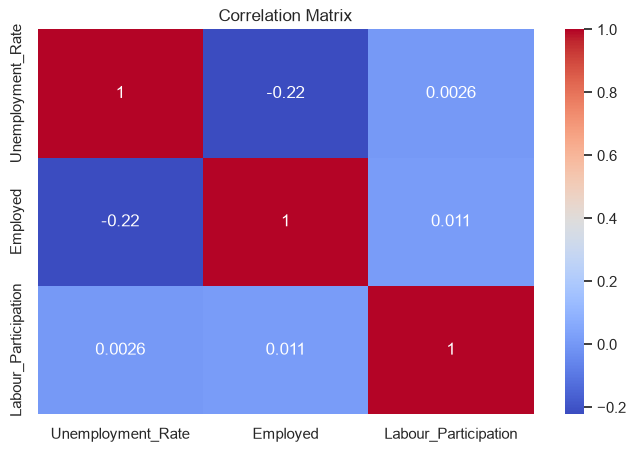

In [33]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[["Unemployment_Rate", "Employed", "Labour_Participation"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

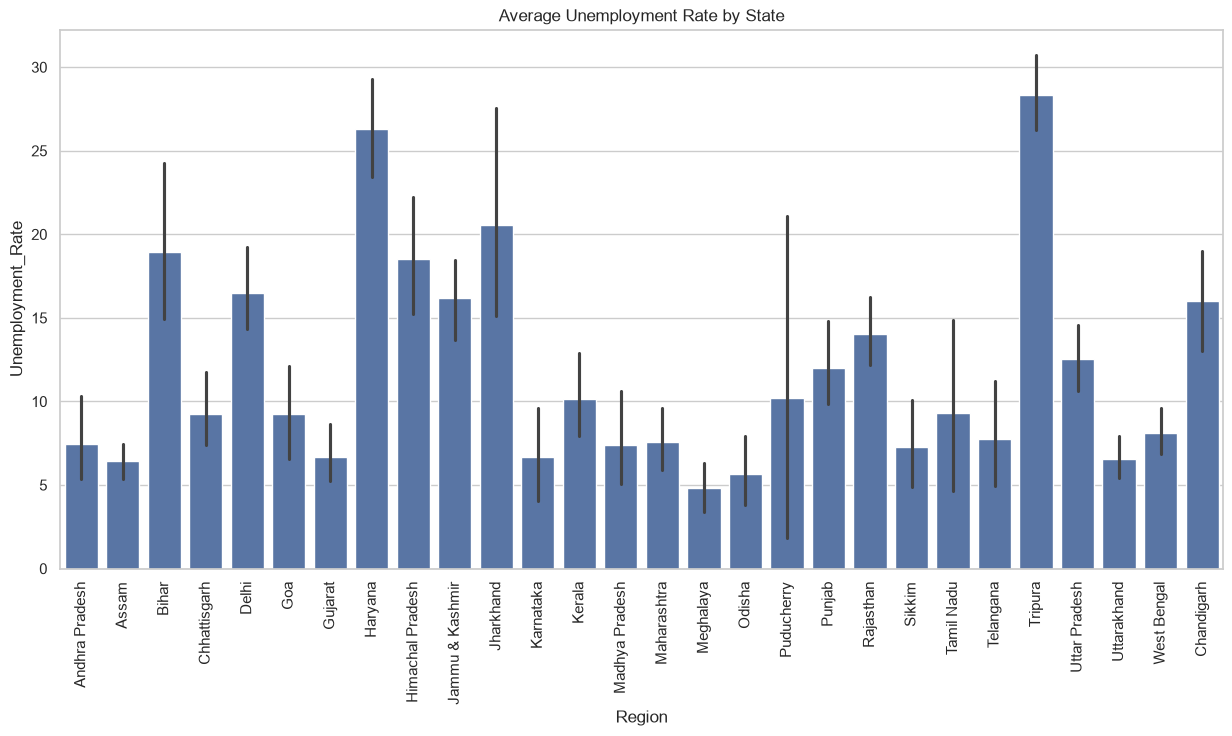

In [34]:
plt.figure(figsize=(15,7))

sns.barplot(
    x="Region",
    y="Unemployment_Rate",
    data=df,
    estimator=np.mean
)

plt.xticks(rotation=90)

plt.title("Average Unemployment Rate by State")

plt.show()

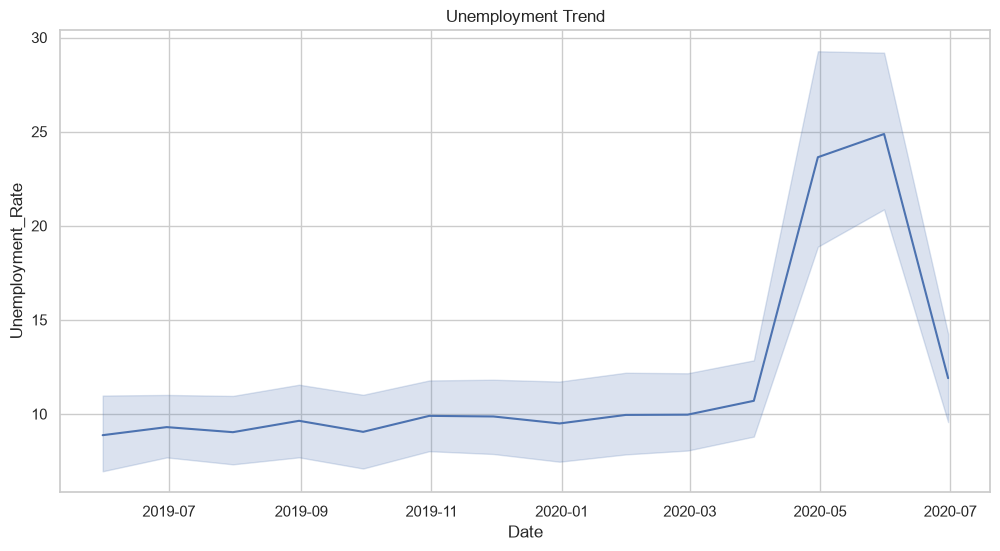

In [35]:
plt.figure(figsize=(12,6))

sns.lineplot(
    x="Date",
    y="Unemployment_Rate",
    data=df
)

plt.title("Unemployment Trend")

plt.show()

In [36]:
top = df.groupby("Region")["Unemployment_Rate"].mean().sort_values(ascending=False)

print(top.head(10))

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Unemployment_Rate, dtype: float64


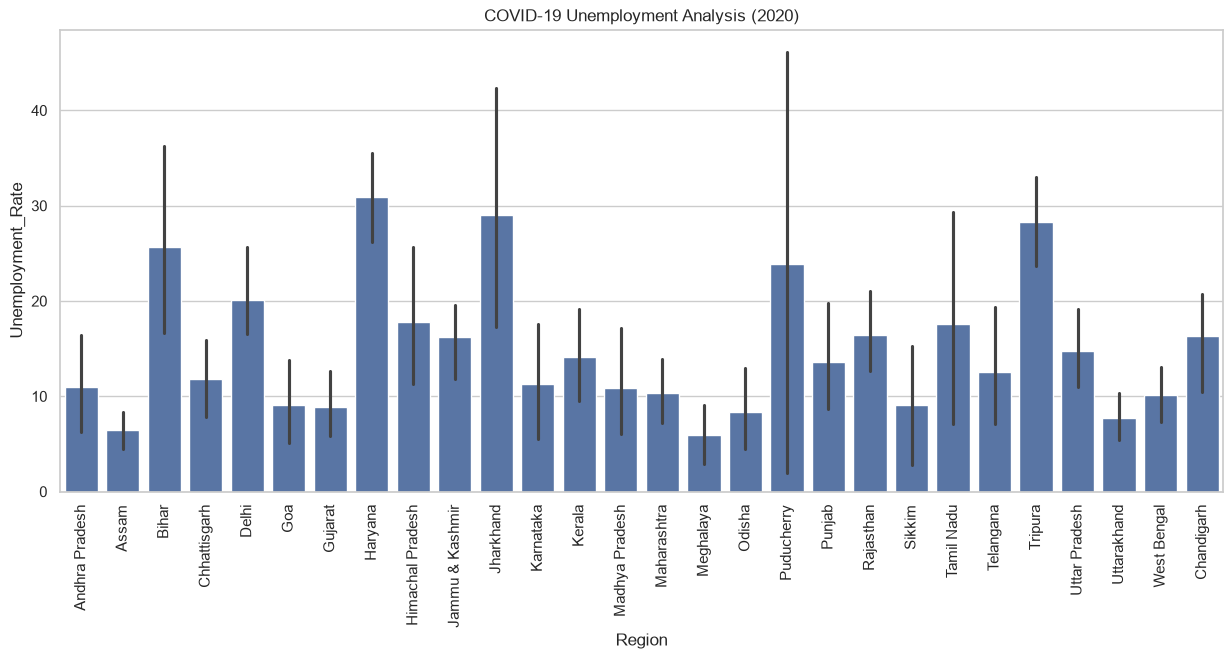

In [37]:
covid = df[df["Year"] == 2020]

plt.figure(figsize=(15,6))

sns.barplot(
    x="Region",
    y="Unemployment_Rate",
    data=covid,
    estimator=np.mean
)

plt.xticks(rotation=90)

plt.title("COVID-19 Unemployment Analysis (2020)")

plt.show()

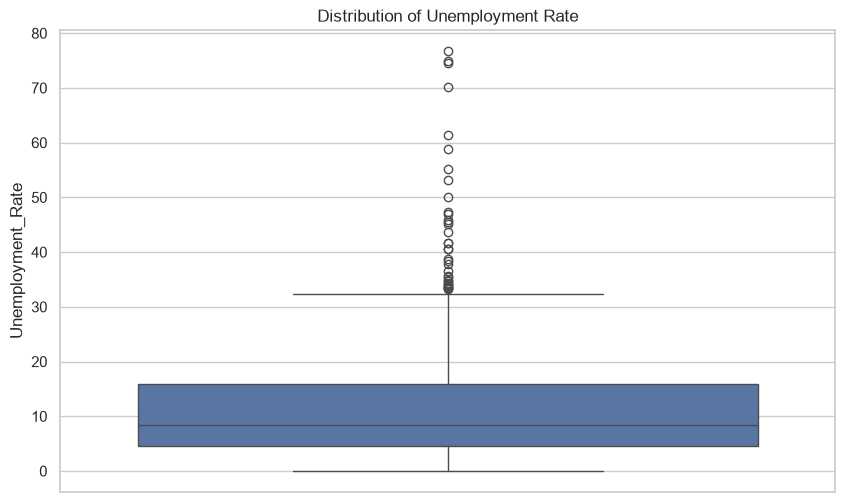

In [38]:
plt.figure(figsize=(10,6))

sns.boxplot(y=df["Unemployment_Rate"])

plt.title("Distribution of Unemployment Rate")

plt.show()

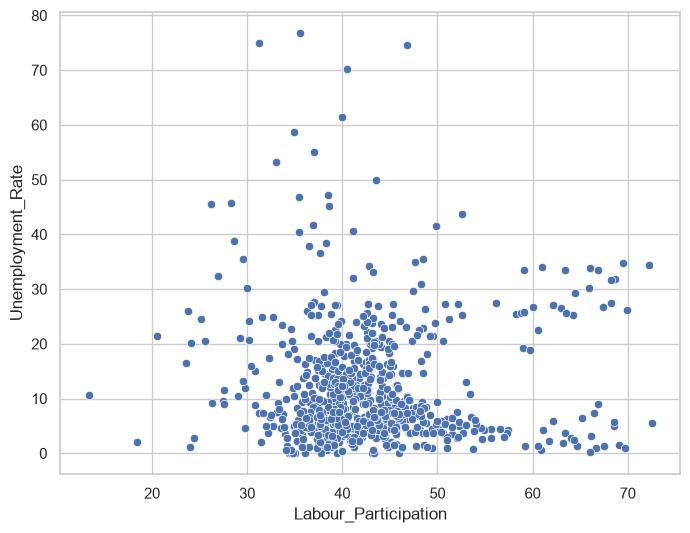

In [39]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Labour_Participation",
    y="Unemployment_Rate",
    data=df
)

plt.show()

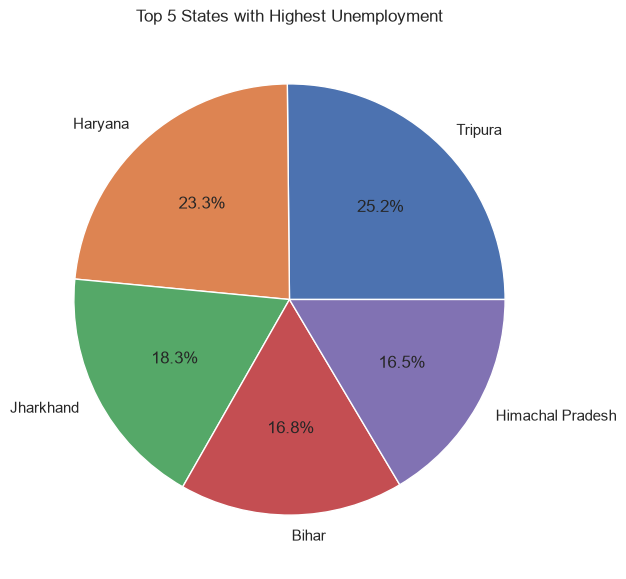

In [40]:
top5 = df.groupby("Region")["Unemployment_Rate"].mean().nlargest(5)

plt.figure(figsize=(7,7))

plt.pie(top5.values,
        labels=top5.index,
        autopct="%1.1f%%")

plt.title("Top 5 States with Highest Unemployment")

plt.show()

In [41]:
print("Average Unemployment Rate :", round(df["Unemployment_Rate"].mean(),2))

print("Highest State :",
      df.groupby("Region")["Unemployment_Rate"].mean().idxmax())

print("Lowest State :",
      df.groupby("Region")["Unemployment_Rate"].mean().idxmin())

Average Unemployment Rate : 11.79
Highest State : Tripura
Lowest State : Meghalaya
